In [1]:
import os
import datetime as dt
import numpy as np
import pandas as pd
import yfinance as yf

np.random.seed(42)

DATA_DIR = "data"
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

UNIVERSE_TICKERS = [
    "SPY", "QQQ", "SMH",
    "XLK", "XLY", "IWM",
    "ARKK", "SHV"
]

end_date = dt.date.today()
start_date = end_date - dt.timedelta(days=20 * 365)

raw_data = yf.download(UNIVERSE_TICKERS, start=start_date, end=end_date, auto_adjust=False)
adj_prices = raw_data['Adj Close'].copy()

adj_prices = adj_prices.ffill()

output_path = os.path.join(DATA_DIR, "Prezzi_Reali_HighBeta.xlsx")
adj_prices.to_excel(output_path)

[*********************100%***********************]  8 of 8 completed


In [2]:
input_path = os.path.join("data", "Prezzi_Reali_HighBeta.xlsx")
daily_prices = pd.read_excel(input_path, index_col=0)

daily_sma_100 = daily_prices.rolling(window=100, min_periods=100).mean()

monthly_prices = daily_prices.resample('ME').last()
monthly_sma_100 = daily_sma_100.resample('ME').last()

last_observed_day = daily_prices.index[-1]
if not last_observed_day.is_month_end:
    monthly_prices = monthly_prices.iloc[:-1]
    monthly_sma_100 = monthly_sma_100.iloc[:-1]

monthly_returns_1m = monthly_prices.pct_change(periods=1)
monthly_momentum_3m = monthly_prices.pct_change(periods=3)
monthly_momentum_6m = monthly_prices.pct_change(periods=6)

In [3]:
trend_filter = monthly_prices > monthly_sma_100
acceleration_filter = monthly_momentum_3m > 0

structural_alpha_signal = trend_filter & acceleration_filter

signal_matrix_path = os.path.join("data", "Semaforo_Structural_Alpha.xlsx")
structural_alpha_signal.to_excel(signal_matrix_path)

In [4]:
TOP_N_SELECT = 2
MOMENTUM_HYSTERESIS_BUFFER = 0.1
MAX_ASSET_WEIGHT = 0.50

target_weights = pd.DataFrame(0.0, index=structural_alpha_signal.index, columns=monthly_prices.columns)
prior_rebalance_holdings = []

for date_idx in structural_alpha_signal.index:
    eligible_assets = structural_alpha_signal.loc[date_idx][structural_alpha_signal.loc[date_idx] == True].index.tolist()
    if 'SHV' in eligible_assets:
        eligible_assets.remove('SHV')
        
    if not eligible_assets:
        target_weights.loc[date_idx, 'SHV'] = 1.0
        prior_rebalance_holdings = ['SHV']
    else:
        raw_signal_strength = monthly_momentum_3m.loc[date_idx, eligible_assets].copy()
        
        for asset in prior_rebalance_holdings:
            if asset in raw_signal_strength.index:
                raw_signal_strength[asset] += MOMENTUM_HYSTERESIS_BUFFER
                
        selected_assets = raw_signal_strength.nlargest(TOP_N_SELECT)
        
        if len(selected_assets) == 1:
            single_winner = selected_assets.index[0]
            target_weights.loc[date_idx, single_winner] = MAX_ASSET_WEIGHT
            target_weights.loc[date_idx, 'SHV'] = 1.0 - MAX_ASSET_WEIGHT
        else:
            equal_allocation = 1.0 / len(selected_assets)
            for etf in selected_assets.index:
                target_weights.loc[date_idx, etf] = equal_allocation
                
        prior_rebalance_holdings = selected_assets.index.tolist()

                   STRATEGY PERFORMANCE ANALYTICS                        
                                      CAGR Annualized Volatility Sharpe Ratio Max Drawdown
Strategy Gross (Unadjusted)         17.73%                17.77%         0.88       -21.3%
Strategy Net (Realistic Execution)  17.54%                17.77%         0.87       -21.5%
Benchmark (S&P 500)                 11.36%                15.34%         0.61       -50.8%



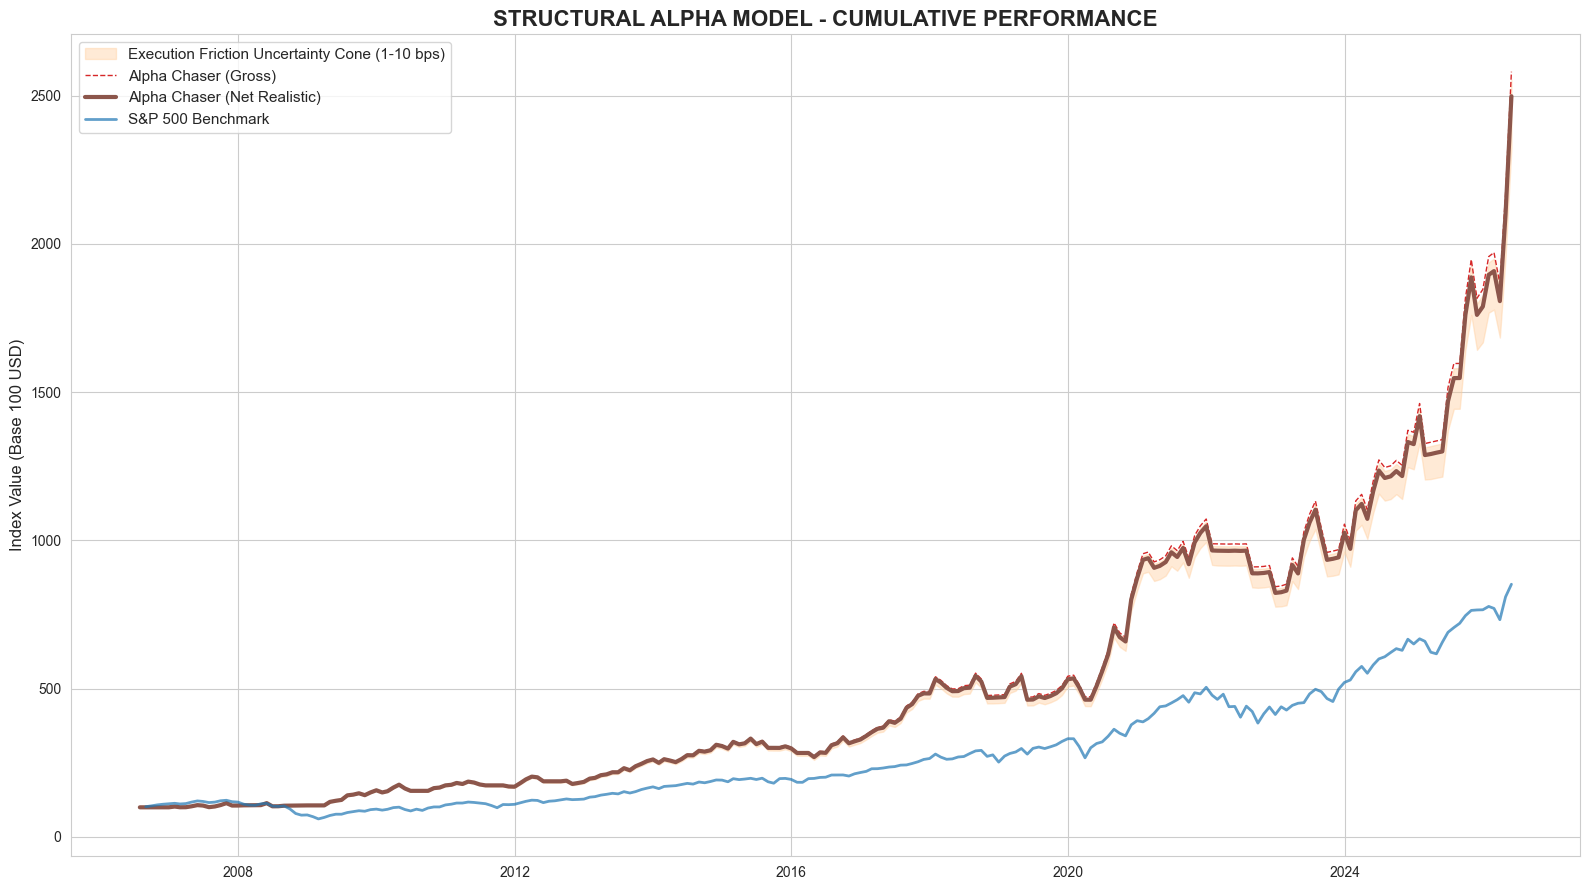

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

OPTIMISTIC_TRANSACTION_COST = 0.0001
PESSIMISTIC_TRANSACTION_COST = 0.0010

first_active_month = target_weights[target_weights.sum(axis=1) > 0].index[0]

gross_strategy_returns = (target_weights.shift(1) * monthly_returns_1m).sum(axis=1).loc[first_active_month:]
benchmark_returns = monthly_returns_1m['SPY'].loc[first_active_month:]

turnover_matrix = target_weights.diff().abs().sum(axis=1)
turnover_matrix.loc[first_active_month] = 1.0

cost_scenario_min = (turnover_matrix.shift(1) * OPTIMISTIC_TRANSACTION_COST).fillna(0).loc[first_active_month:]
cost_scenario_max = (turnover_matrix.shift(1) * PESSIMISTIC_TRANSACTION_COST).fillna(0).loc[first_active_month:]

net_returns_min = gross_strategy_returns - cost_scenario_min
net_returns_max = gross_strategy_returns - cost_scenario_max

asset_class_execution_spreads = {
    'SPY': 0.0002,
    'QQQ': 0.0003,
    'XLK': 0.0003,
    'XLY': 0.0003,
    'SMH': 0.0005,
    'IWM': 0.0004,
    'ARKK': 0.0008,
    'SHV': 0.0001
}
execution_spreads_series = pd.Series(asset_class_execution_spreads)

granular_turnover = target_weights.diff().abs()
granular_turnover.loc[first_active_month] = target_weights.loc[first_active_month]

realistic_friction_drag = (granular_turnover * execution_spreads_series).sum(axis=1).shift(1).fillna(0).loc[first_active_month:]
net_returns_realistic = gross_strategy_returns - realistic_friction_drag

equity_curve_gross = (1 + gross_strategy_returns).cumprod() * 100
equity_curve_net_min = (1 + net_returns_min).cumprod() * 100
equity_curve_net_max = (1 + net_returns_max).cumprod() * 100
equity_curve_net_realistic = (1 + net_returns_realistic).cumprod() * 100
equity_curve_benchmark = (1 + benchmark_returns).cumprod() * 100

def compute_performance_analytics(returns_series):
    n_years = len(returns_series) / 12
    cagr_metric = ((1 + ((1 + returns_series).prod() - 1)) ** (1 / n_years)) - 1
    vol_metric = returns_series.std() * np.sqrt(12)
    rolling_peak = (1 + returns_series).cumprod().cummax()
    drawdown_series = ((1 + returns_series).cumprod() / rolling_peak) - 1
    max_dd_metric = drawdown_series.min()
    
    rf_rate = 0.02
    sharpe_metric = (cagr_metric - rf_rate) / vol_metric if vol_metric > 0 else 0.0
    
    return {
        "CAGR": f"{cagr_metric * 100:.2f}%",
        "Annualized Volatility": f"{vol_metric * 100:.2f}%",
        "Sharpe Ratio": f"{sharpe_metric:.2f}",
        "Max Drawdown": f"{max_dd_metric * 100:.1f}%"
    }

performance_summary_df = pd.DataFrame({
    "Strategy Gross (Unadjusted)": compute_performance_analytics(gross_strategy_returns),
    "Strategy Net (Realistic Execution)": compute_performance_analytics(net_returns_realistic),
    "Benchmark (S&P 500)": compute_performance_analytics(benchmark_returns)
}).T

print("=========================================================================")
print("                   STRATEGY PERFORMANCE ANALYTICS                        ")
print("=========================================================================")
print(performance_summary_df.to_string())
print("=========================================================================\n")

plt.figure(figsize=(16, 9))
sns.set_style("whitegrid")

plt.fill_between(
    equity_curve_net_min.index, 
    equity_curve_net_max, 
    equity_curve_net_min, 
    color='#ffcc99', 
    alpha=0.4, 
    label='Execution Friction Uncertainty Cone (1-10 bps)'
)

plt.plot(equity_curve_gross, label='Alpha Chaser (Gross)', color='#d62728', linewidth=1, linestyle='--')
plt.plot(equity_curve_net_realistic, label='Alpha Chaser (Net Realistic)', color='#8c564b', linewidth=3)
plt.plot(equity_curve_benchmark, label='S&P 500 Benchmark', color='#1f77b4', linewidth=2, alpha=0.7)

plt.title("STRUCTURAL ALPHA MODEL - CUMULATIVE PERFORMANCE", fontsize=16, fontweight='bold')
plt.ylabel("Index Value (Base 100 USD)", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
active_weights_history = target_weights.loc[first_active_month:]
historical_allocation_summary = pd.DataFrame(index=active_weights_history.columns)

n_total_active_periods = len(active_weights_history)

historical_allocation_summary['Months Invested'] = (active_weights_history > 0).sum()
historical_allocation_summary['Allocation Frequency'] = ((historical_allocation_summary['Months Invested'] / n_total_active_periods) * 100).round(1)
historical_allocation_summary['Active Mean Weight'] = (active_weights_history[active_weights_history > 0].mean() * 100).round(1)
historical_allocation_summary['Peak Weight Recorded'] = (active_weights_history.max() * 100).round(1)

historical_allocation_summary = historical_allocation_summary.sort_values(by='Months Invested', ascending=False)

stats_export_path = os.path.join("data", "Allocation_Stats_Alpha_Chaser.xlsx")
historical_allocation_summary.to_excel(stats_export_path)

In [8]:
evaluation_date = target_weights.index[-1]
unadjusted_model_weights = target_weights.iloc[-1]
systematic_target_allocations = unadjusted_model_weights[unadjusted_model_weights > 0].sort_values(ascending=False)

discretionary_macro_overlays = {
    'SPY': 0.0,
    'QQQ': 0.0,
    'SMH': 0.0,
    'XLK': 0.0,
    'XLY': 0.0,
    'IWM': 0.0,
    'ARKK': 0.0,
    'SHV': 0.0
}

portfolio_audit_log = "Execution of Alpha Chaser systematic model (2-Asset top sizing, 10% Hysteresis buffer, 50% Asset Cap). Zero discretionary overrides applied."

final_execution_targets = {}
eval_universe_assets = set(unadjusted_model_weights.index).union(set(discretionary_macro_overlays.keys()))

for ticker in eval_universe_assets:
    base_w = unadjusted_model_weights.get(ticker, 0.0)
    overlay_w = discretionary_macro_overlays.get(ticker, 0.0)
    
    net_w = max(0.0, base_w + overlay_w)
    if net_w > 0.0001:
        final_execution_targets[ticker] = net_w

print("=========================================================================")
print(f"PORTFOLIO AUDIT REPORT - EVALUATION DATE: {evaluation_date.strftime('%Y-%m-%d')}")
print("=========================================================================")
print(f"Audit Trail: {portfolio_audit_log}\n")

print("TARGET ALLOCATION BREAKDOWN:")
for ticker, w_final in sorted(final_execution_targets.items(), key=lambda item: item[1], reverse=True):
    w_base = unadjusted_model_weights.get(ticker, 0.0)
    w_over = discretionary_macro_overlays.get(ticker, 0.0)
    
    if abs(w_over) > 0.0001:
        prefix = "+" if w_over > 0 else ""
        delta_label = f"[Systematic Base: {w_base * 100:.1f}% | Discretionary Delta: {prefix}{w_over * 100:.1f}%]"
    else:
        delta_label = "[Strict Systematic Execution]"
        
    print(f"  Ticker: {ticker:<5} | Allocation Target: {w_final * 100:>5.1f}%  {delta_label}")

total_portfolio_exposure = sum(final_execution_targets.values())
if abs(total_portfolio_exposure - 1.0) > 0.001:
    raise ValueError(f"Execution Halt: Gross target exposure equals {total_portfolio_exposure * 100:.2f}%. Mandatory 100% normalization violated.")

PORTFOLIO AUDIT REPORT - EVALUATION DATE: 2026-05-31
Audit Trail: Execution of Alpha Chaser systematic model (2-Asset top sizing, 10% Hysteresis buffer, 50% Asset Cap). Zero discretionary overrides applied.

TARGET ALLOCATION BREAKDOWN:
  Ticker: XLK   | Allocation Target:  50.0%  [Strict Systematic Execution]
  Ticker: SMH   | Allocation Target:  50.0%  [Strict Systematic Execution]


In [9]:
NET_ASSET_VALUE_EUR = 100000

current_ledger_holdings_eur = {
    'SPY': 0.0,
    'QQQ': 0.0,
    'SMH': 0.0,
    'XLK': 0.0,
    'XLY': 0.0,
    'IWM': 0.0,
    'ARKK': 0.0,
    'SHV': 0.0
}

ucits_translation_table = {
    'SPY':  {'ticker': 'SXR8', 'isin': 'IE00B5BMR087', 'name': 'iShares Core S&P 500 UCITS ETF USD (Acc)'},
    'QQQ':  {'ticker': 'SXRV', 'isin': 'IE00B53SZB19', 'name': 'iShares Nasdaq 100 UCITS ETF USD (Acc)'},
    'SMH':  {'ticker': 'SEC0', 'isin': 'IE000I8KRLL9', 'name': 'iShares MSCI Global Semiconductors UCITS ETF USD (Acc)'},
    'XLK':  {'ticker': 'QDVE', 'isin': 'IE00B3WJKG14', 'name': 'iShares S&P 500 Information Technology Sector UCITS ETF USD (Acc)'},
    'XLY':  {'ticker': 'IUCD', 'isin': 'IE00B4MCHD36', 'name': 'iShares S&P 500 Consumer Discretionary Sector UCITS ETF USD (Acc)'},
    'IWM':  {'ticker': 'ZPRR', 'isin': 'IE00BJ38QD84', 'name': 'SPDR Russell 2000 U.S. Small Cap UCITS ETF (Acc)'},
    'ARKK': {'ticker': 'ARKK', 'isin': 'IE000GA3D489', 'name': 'ARK Innovation UCITS ETF USD (Acc)'},
    'SHV':  {'ticker': 'IBCC', 'isin': 'IE00BGSF1X88', 'name': 'iShares USD Treasury Bond 0-1yr UCITS ETF USD (Acc)'}
}

combined_ledger_assets = set(final_execution_targets.keys()).union(set(current_ledger_holdings_eur.keys()))
execution_blotter = []

for ticker in combined_ledger_assets:
    target_notional_eur = NET_ASSET_VALUE_EUR * final_execution_targets.get(ticker, 0.0)
    current_notional_eur = current_ledger_holdings_eur.get(ticker, 0.0)
    
    notional_delta_eur = target_notional_eur - current_notional_eur
    
    if abs(notional_delta_eur) > 50.00:
        order_side = "BUY" if notional_delta_eur > 0 else "SELL"
        execution_blotter.append((order_side, ticker, abs(notional_delta_eur)))

execution_blotter.sort(key=lambda item: item[0], reverse=True)

blotter_export_df = pd.DataFrame(columns=["Order Side", "ISIN", "European Ticker", "Fund Description", "Notional (EUR)"])

for idx, (side, ticker_us, notional) in enumerate(execution_blotter):
    eu_meta = ucits_translation_table.get(ticker_us, {'ticker': ticker_us, 'isin': 'UNMAPPED', 'name': 'UNMAPPED INSTRUMENT'})
    blotter_export_df.loc[idx] = [side, eu_meta['isin'], eu_meta['ticker'], eu_meta['name'], notional]

pd.set_option('display.float_format', lambda val: f'€ {val:,.2f}' if isinstance(val, (int, float)) else str(val))

print("=========================================================================")
print("                      TRADE EXECUTION BLOTTER                            ")
print("=========================================================================")
# Visualizzazione standard a prova di errore (senza .style)
print(blotter_export_df.to_string(index=False))

                      TRADE EXECUTION BLOTTER                            
Order Side         ISIN European Ticker                                                  Fund Description  Notional (EUR)
       BUY IE00B3WJKG14            QDVE iShares S&P 500 Information Technology Sector UCITS ETF USD (Acc)     € 50,000.00
       BUY IE000I8KRLL9            SEC0            iShares MSCI Global Semiconductors UCITS ETF USD (Acc)     € 50,000.00
